<a href="https://colab.research.google.com/github/ChristianAgyapong/Medgemma/blob/main/TASK_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import the tools we need**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

**Load the dataset ( no CSV needed)**

In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame

# For clustering we ignore the target (species) completely
X = df.drop('target', axis=1)  # only the 4 features: sepal length/width, petal length/width

print("Features shape:", X.shape)
print("\nFirst 5 rows (unlabeled):")
print(X.head())

# Very important: Scale the features (K-Means is distance-based!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter scaling (mean ≈ 0, std ≈ 1):")
print(pd.DataFrame(X_scaled, columns=X.columns).head())

Features shape: (150, 4)

First 5 rows (unlabeled):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

After scaling (mean ≈ 0, std ≈ 1):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.900681          1.019004          -1.340227         -1.315444
1          -1.143017         -0.131979          -1.340227         -1.315444
2          -1.385353          0.328414          -1.397064         -1.315444
3          -1.506521          0.098217          -1.283389         -1.315444
4          -1.021849          1.249201          -1.340227         -1.315444


**Prepare X (features) and y (target)**

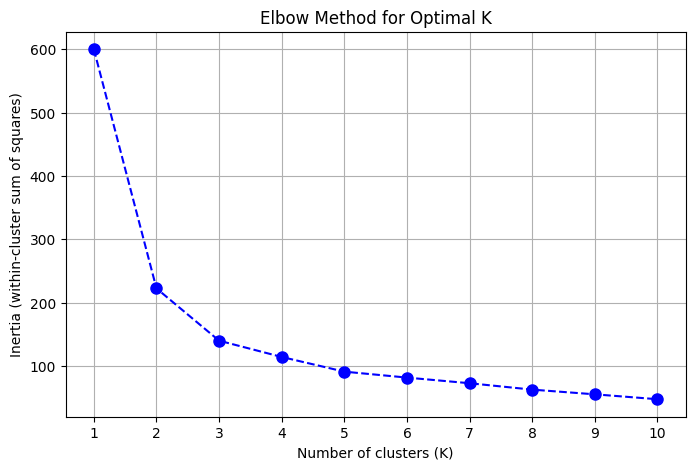

In [ ]:
inertias = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, 'bo--', markersize=8)
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (within-cluster sum of squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(k_range)
plt.grid(True)
plt.show()

**Split into train + test**

In [ ]:
optimal_k = 3   # from elbow method

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Get cluster labels (0, 1, 2 for each flower)
labels = kmeans.labels_

print("Cluster sizes:", np.bincount(labels))
print("Cluster centers (scaled):")
print(kmeans.cluster_centers_)

Cluster sizes: [53 50 47]
Cluster centers (scaled):
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


**Change words (categories) to numbers**

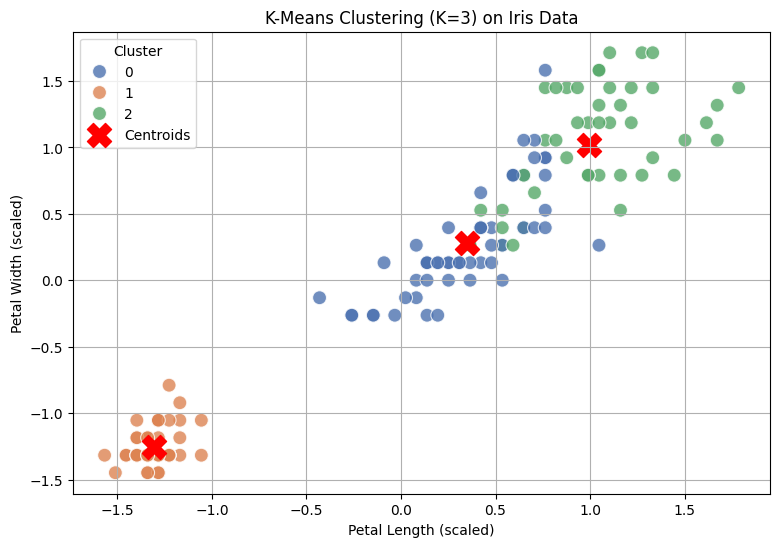

In [ ]:
# Use petal length & petal width (features 2 & 3) — they separate Iris best
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_scaled[:, 2], y=X_scaled[:, 3],
    hue=labels,
    palette='deep',
    s=100,
    alpha=0.8
)

# Plot cluster centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 2], centers[:, 3], c='red', marker='X', s=300, label='Centroids')

plt.xlabel('Petal Length (scaled)')
plt.ylabel('Petal Width (scaled)')
plt.title(f'K-Means Clustering (K={optimal_k}) on Iris Data')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

**Scale (make numbers similar size) – Age and Fare only**

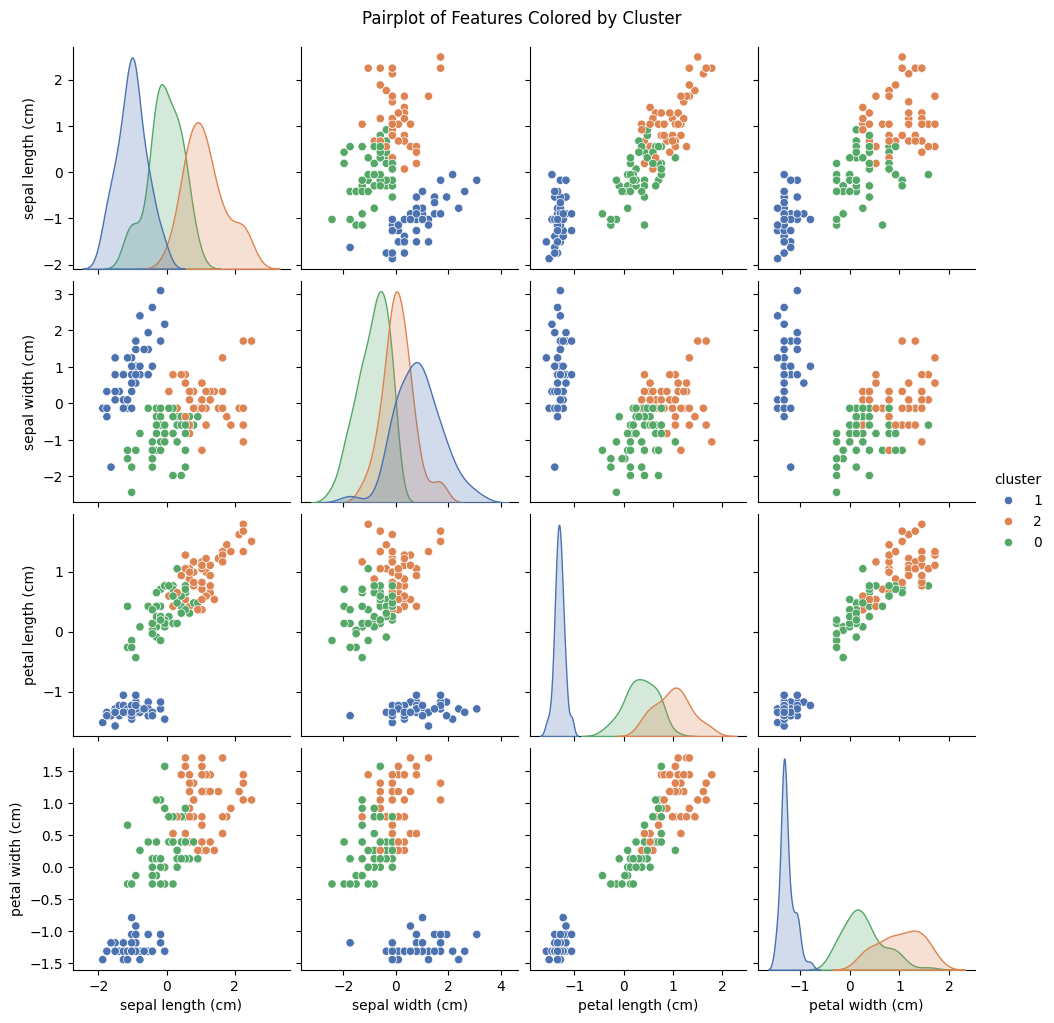

In [ ]:
df_plot = pd.DataFrame(X_scaled, columns=iris.feature_names)
df_plot['cluster'] = labels.astype(str)

sns.pairplot(df_plot, hue='cluster', palette='deep', diag_kind='kde')
plt.suptitle('Pairplot of Features Colored by Cluster', y=1.02)
plt.show()

**Separate features (X) and target (y)**

In [ ]:
# Quick interpretation table
cluster_summary = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=iris.feature_names,
    index=[f'Cluster {i}' for i in range(optimal_k)]
).round(2)

print("Cluster centers (original scale):")
print(cluster_summary)

print("\nInterpretation:")
print("- Cluster 0: Usually small petals → likely 'setosa'")
print("- Cluster 1 & 2: Larger petals, but different sepal/petal ratios → 'versicolor' & 'virginica'")

Cluster centers (original scale):
           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster 0               5.80              2.67               4.37   
Cluster 1               5.01              3.43               1.46   
Cluster 2               6.78              3.10               5.51   

           petal width (cm)  
Cluster 0              1.41  
Cluster 1              0.25  
Cluster 2              1.97  

Interpretation:
- Cluster 0: Usually small petals → likely 'setosa'
- Cluster 1 & 2: Larger petals, but different sepal/petal ratios → 'versicolor' & 'virginica'


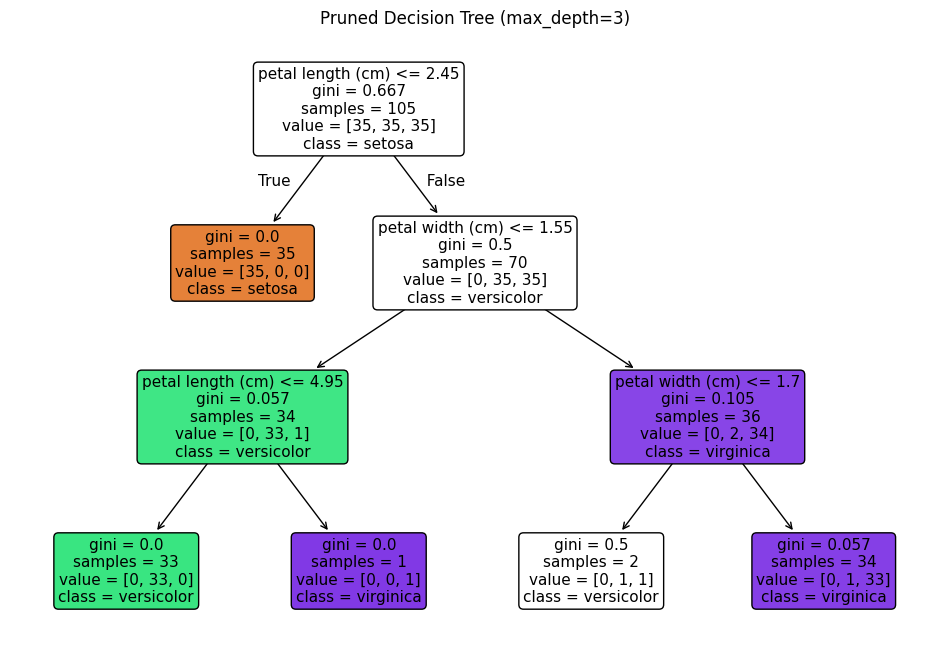

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(
    tree_pruned,                     # or tree_pruned2
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Pruned Decision Tree (max_depth=3)")
plt.show()

Accuracy: 0.978

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



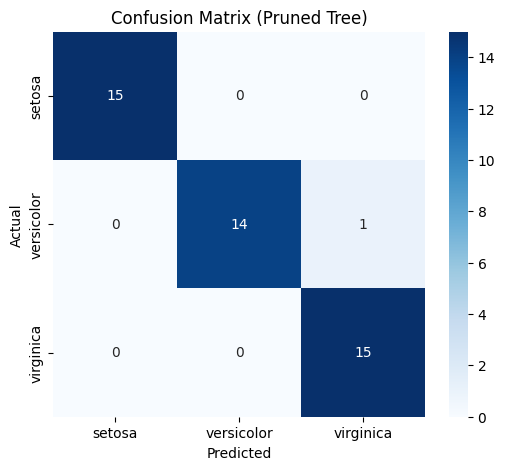

In [ ]:
# Use the pruned model for final evaluation
y_pred = tree_pruned.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Pruned Tree)')
plt.show()

In [ ]:
# Coefficients DataFrame
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0].round(4)
}).sort_values('Coefficient', ascending=False)

print("Top positive coefficients (increase churn probability):")
print(coef_df.head(10))

print("\nTop negative coefficients (decrease churn probability):")
print(coef_df.tail(10))

# Odds ratios = exp(coefficient) → how much odds change per 1 unit increase
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient']).round(3)
print("\nWith Odds Ratios:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio']].head(10))

Top positive coefficients (increase churn probability):
                           Feature  Coefficient
10     InternetService_Fiber optic       1.1807
3                     TotalCharges       0.5278
28  PaymentMethod_Electronic check       0.3928
21                 StreamingTV_Yes       0.3748
26            PaperlessBilling_Yes       0.3742
23             StreamingMovies_Yes       0.3732
9                MultipleLines_Yes       0.3616
0                    SeniorCitizen       0.1479
29      PaymentMethod_Mailed check       0.0819
17            DeviceProtection_Yes       0.0331

Top negative coefficients (decrease churn probability):
                               Feature  Coefficient
12  OnlineSecurity_No internet service      -0.1725
6                       Dependents_Yes      -0.2264
8       MultipleLines_No phone service      -0.2693
19                     TechSupport_Yes      -0.2993
13                  OnlineSecurity_Yes      -0.3491
2                       MonthlyCharges      -0.